https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadshahidazeem/customer-churn-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-churn-dataset' dataset.
Path to dataset files: /kaggle/input/customer-churn-dataset


In [ ]:
!ls /root/.cache/kagglehub/datasets/muhammadshahidazeem/customer-churn-dataset/versions/1

customer_churn_dataset-testing-master.csv
customer_churn_dataset-training-master.csv


In [5]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, 'customer_churn_dataset-testing-master.csv'))
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [ ]:
df.head()
df.info()
df.describe() # получаю сводную статистику по каждому признаку

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print('Num:', num_cols)
print('Cat:', cat_cols)

Num: Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')
Cat: Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')


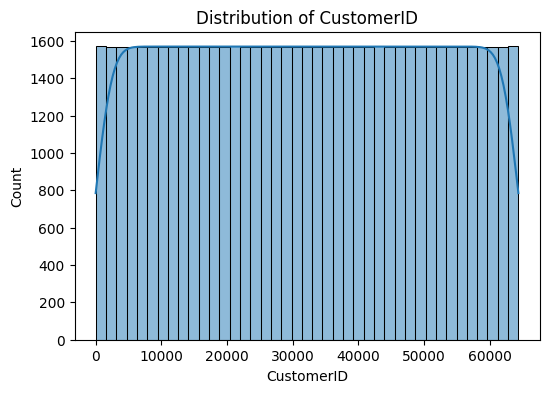

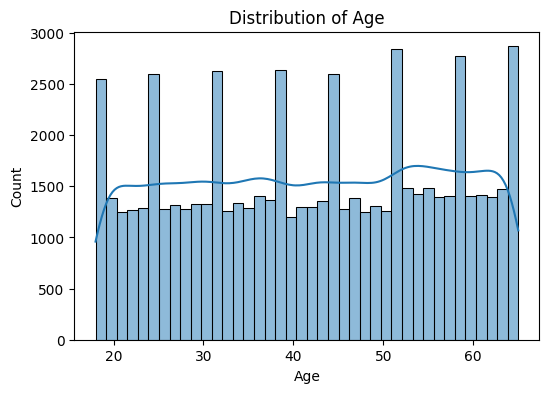

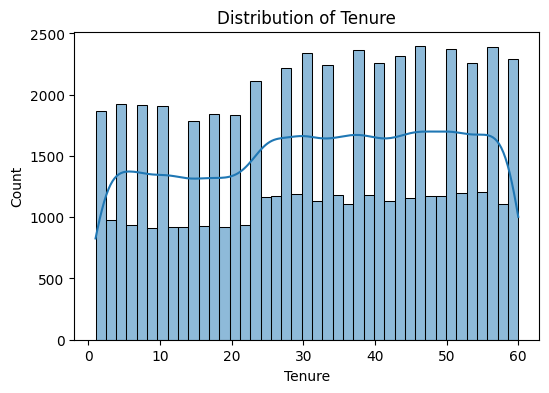

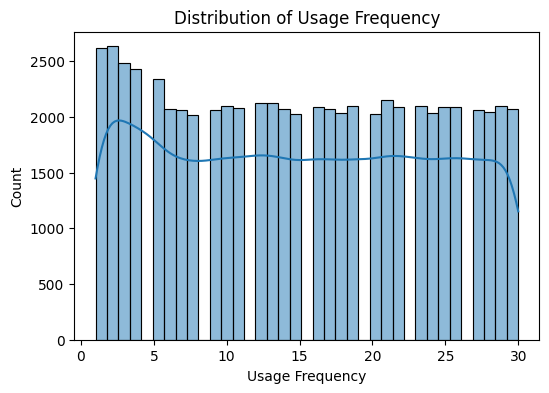

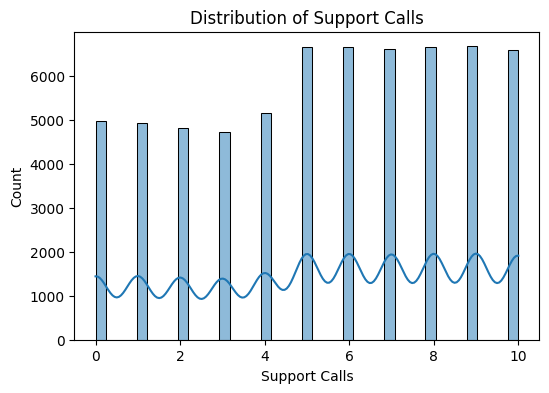

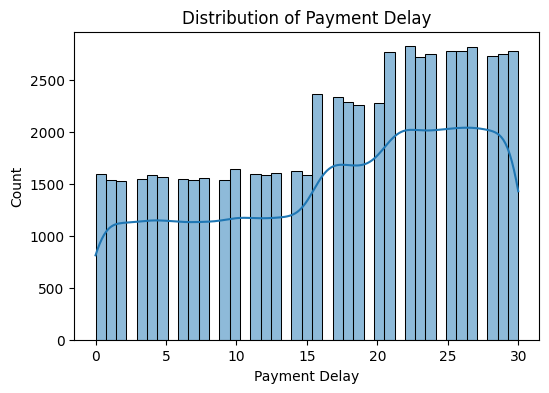

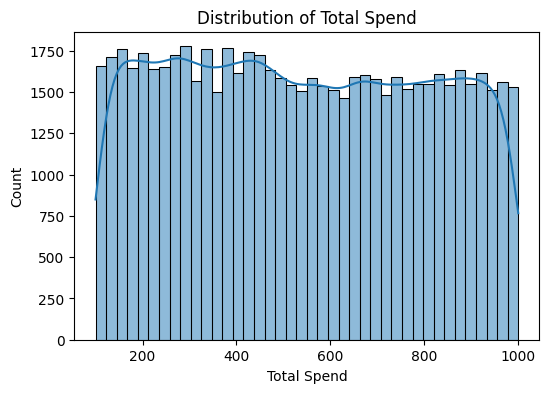

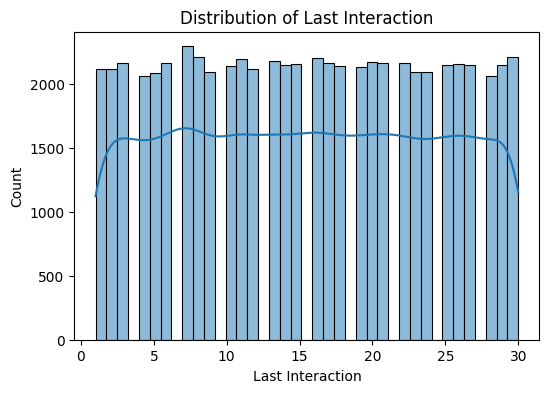

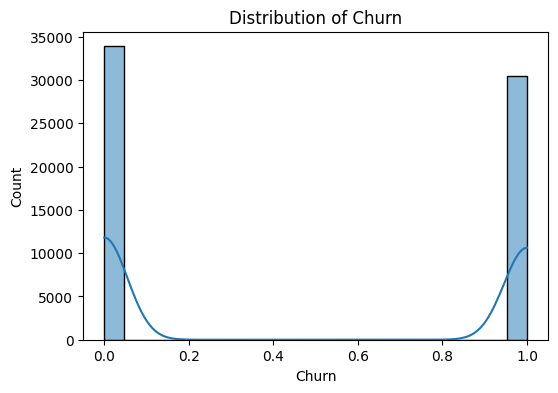

In [ ]:
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()

In [ ]:
df.groupby('Age').count()['CustomerID'].sort_values()

,CustomerID
Age,
40,1196
21,1251
24,1252
48,1253
33,1257
50,1260
22,1266
18,1274
28,1278


`Payement Delay` - перекос вправо: значения с большими задержками встречаются чаще, чем малые. Это может указывать на наличие группы клиентов с систематическими проблемами оплаты.

`Age, Tenure, Total Spend, Last Interaction` - не похоже на нормальное распределение (колокол)

`Support Calls` - является дискретным (принимает только целые значения), распределен относительно равномерно: поведение клиентов разнообразно

`CustomerID` - равномерное распределение (мусор?)

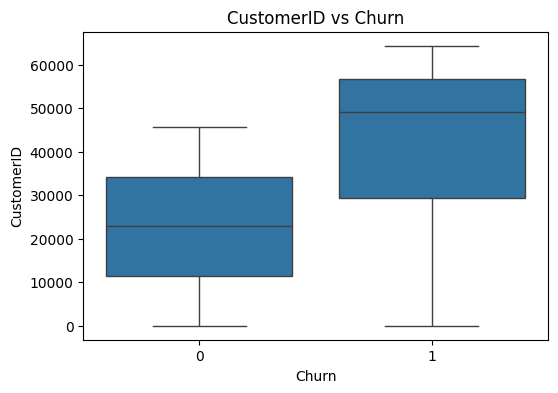

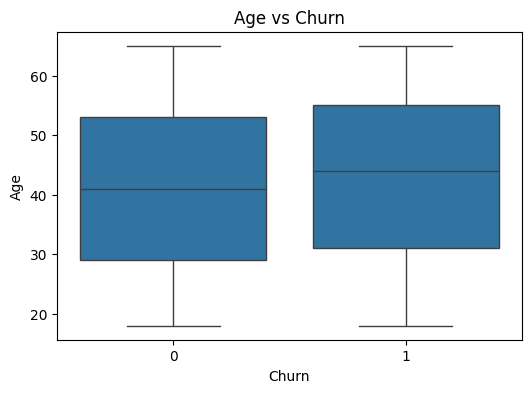

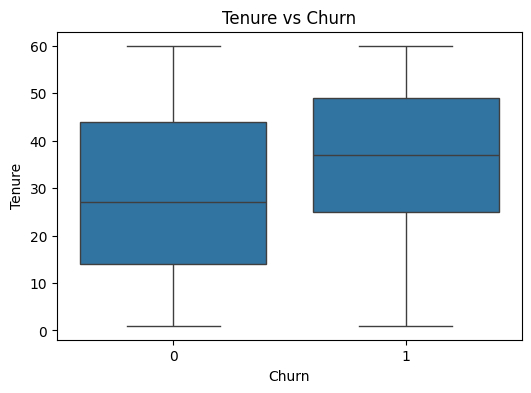

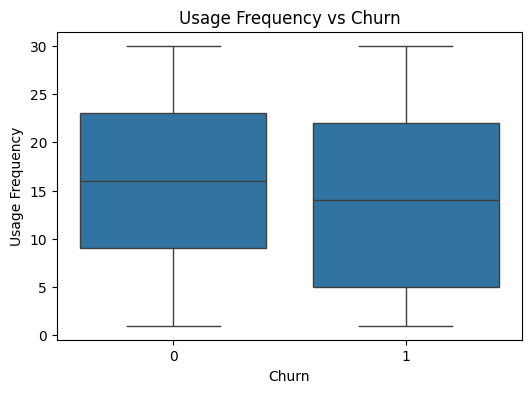

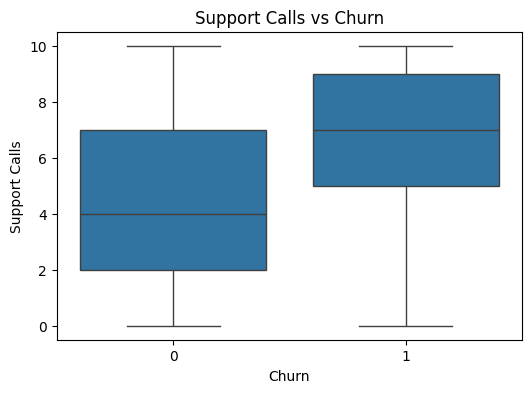

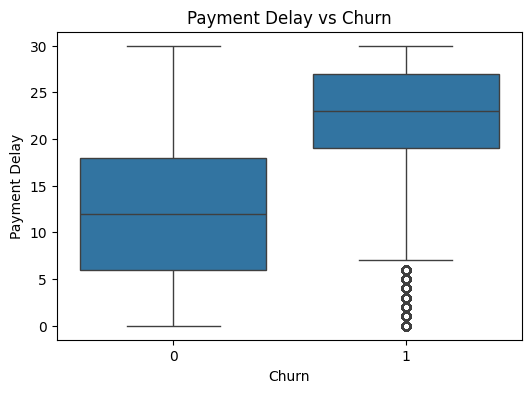

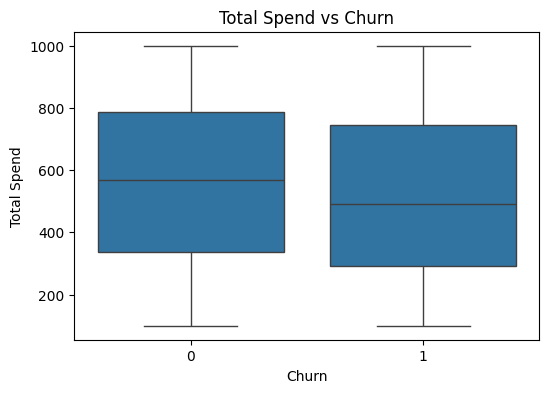

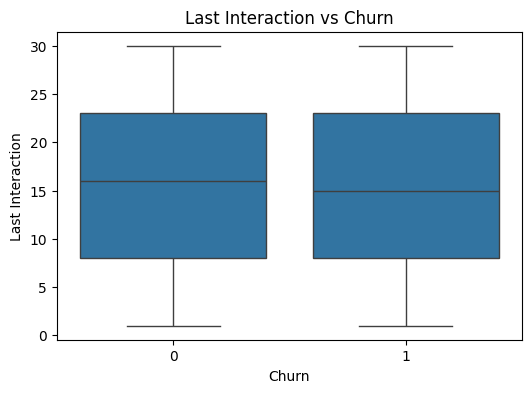

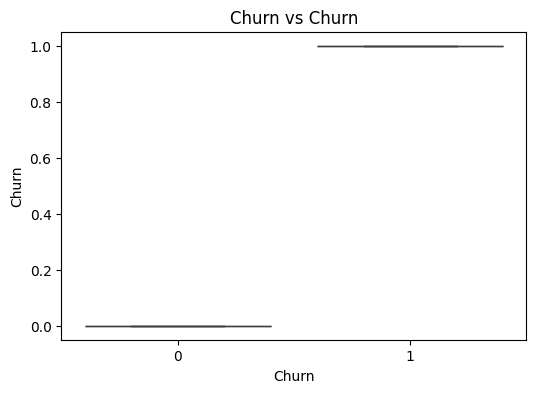

In [ ]:
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x='Churn', y=col, data=df)
  plt.title(f'{col} vs Churn')
  plt.show() # Ящик с усами

DISTRIBUTION OF AGE
*Наблюдение*
Распределение признака Age является относительно равномерным, без выраженного перекоса и крупных выбросов. На гистограмме наблюдаются отдельные пики значений, что может быть связано с дискретной природой признака или синтетическим характером данных.

*Гипотеза*
Возраст клиента не оказывает существенного влияния на вероятность churn.

*Подтверждение*
Boxplot Age vs Churn показывает сильное перекрытие распределений между классами. Средние значения возраста также отличаются незначительно.

*Вывод*
Признак Age обладает низкой предсказательной способностью и слабо связан с churn.

Distribution of Tenure
*Наблюдение*
Признак Tenure распределён достаточно равномерно, при этом более высокие значения встречаются несколько чаще.

*Гипотеза*
Длительность использования сервиса может быть связана с вероятностью churn.

*Подтверждение*
Boxplot Tenure vs Churn показывает, что у клиентов с churn медиана и средние значения Tenure выше.

*Вывод*
Признак Tenure содержит полезную информацию для модели, хотя направление зависимости является нетипичным.

Distribution of Usage Frequency

*Наблюдение*
Признак Usage Frequency распределён без выраженных аномалий, однако более низкие значения встречаются чаще.

*Гипотеза*
Снижение активности пользователя может быть связано с повышенным риском churn.

*Подтверждение*
Boxplot показывает, что у churn-клиентов медиана Usage Frequency немного ниже, однако распределения существенно перекрываются.

*Вывод*
Признак Usage Frequency демонстрирует ограниченную информативность.

Distribution of Support Calls
*Наблюдение*
Признак Support Calls имеет дискретное распределение, так как отражает количество обращений в поддержку.

*Гипотеза*
Частые обращения в поддержку могут свидетельствовать о проблемах клиентов и повышенной вероятности churn.

*Подтверждение*
Boxplot Support Calls vs Churn показывает заметное смещение распределения вверх для churn-клиентов. Среднее количество обращений также значительно выше.

*Вывод*
Support Calls является одним из наиболее информативных признаков для предсказания churn.

Distribution of Payment Delay
*Наблюдение*
Признак Payment Delay имеет неравномерное распределение и содержит значения с большими задержками платежей.

*Гипотеза*
Регулярные задержки платежей связаны с повышенной вероятностью churn.

*Подтверждение*
Boxplot Payment Delay vs Churn показывает наиболее выраженное различие между классами. У churn-клиентов значения Payment Delay значительно выше.

*Вывод*
Payment Delay является одним из сильнейших предикторов churn.

Distribution of Total Spend
*Наблюдение*
Распределение Total Spend близко к равномерному, без выраженных выбросов и перекосов.

*Гипотеза*
Общий объём расходов может оказывать влияние на churn.

*Подтверждение*
Boxplot показывает сильное перекрытие распределений. Средние значения отличаются незначительно.

*Вывод*
Признак Total Spend обладает ограниченной предсказательной способностью.

Distribution of Last Interaction
*Наблюдение*
Признак Last Interaction распределён практически равномерно.

*Гипотеза*
Время с последнего взаимодействия может быть связано с вовлечённостью клиента.

*Подтверждение*
Boxplot Last Interaction vs Churn показывает практически одинаковые распределения между классами.

*Вывод*
Признак Last Interaction практически не влияет на churn.

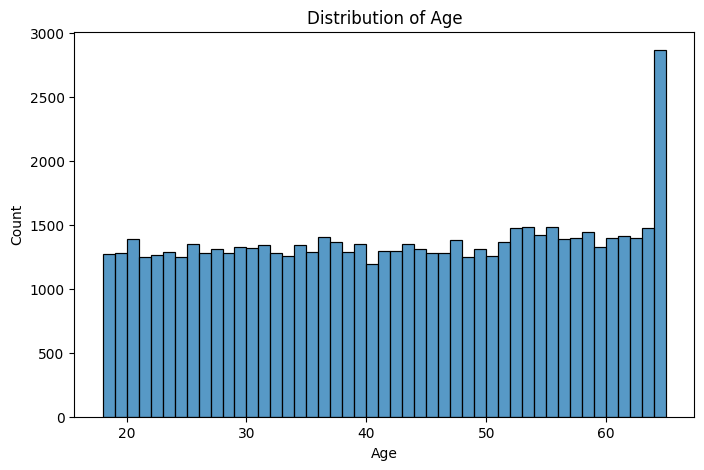

In [6]:
# Работа с AGE
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    binwidth=1,
    kde=False
)

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

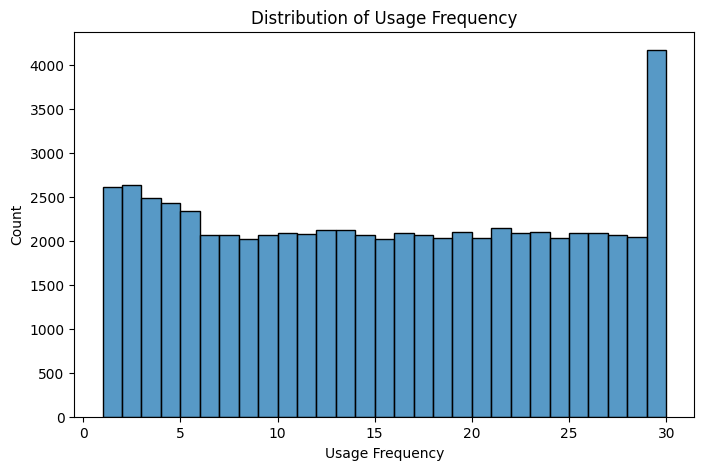

In [8]:
# Usage Frequency
plt.figure(figsize=(8,5))

sns.histplot(
    df['Usage Frequency'],
    binwidth=1,
    kde=False
)

plt.title('Distribution of Usage Frequency')
plt.xlabel('Usage Frequency')
plt.ylabel('Count')

plt.show()

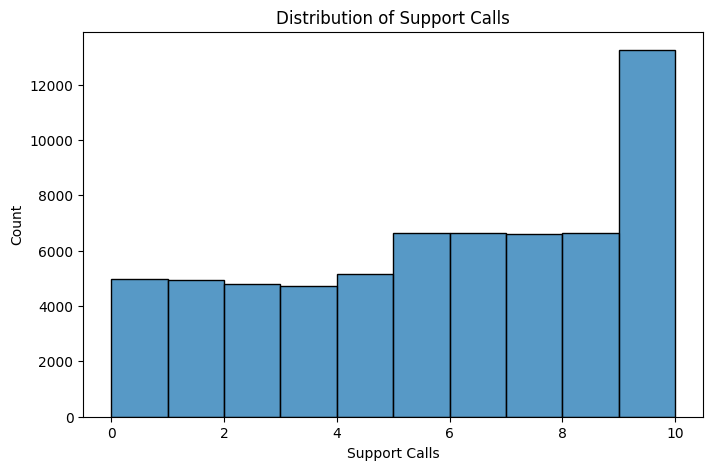

In [9]:
# Support Calls
plt.figure(figsize=(8,5))

sns.histplot(
    df['Support Calls'],
    binwidth=1,
    kde=False
)

plt.title('Distribution of Support Calls')
plt.xlabel('Support Calls')
plt.ylabel('Count')

plt.show()

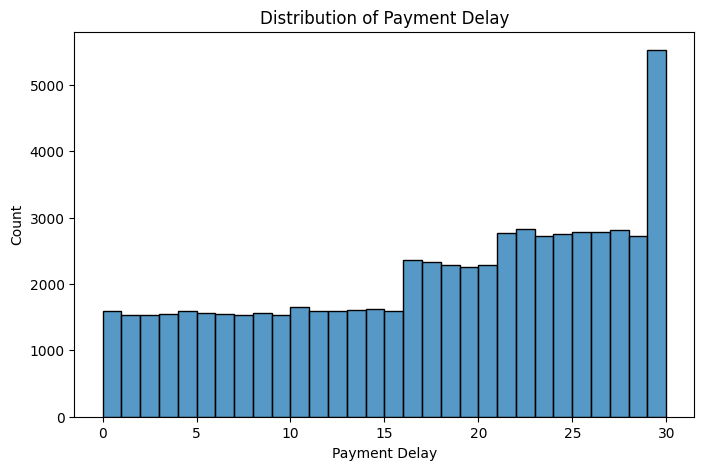

In [11]:
# Payment Delay
plt.figure(figsize=(8,5))

sns.histplot(
    df['Payment Delay'],
    binwidth=1,
    kde=False
)

plt.title('Distribution of Payment Delay')
plt.xlabel('Payment Delay')
plt.ylabel('Count')

plt.show()

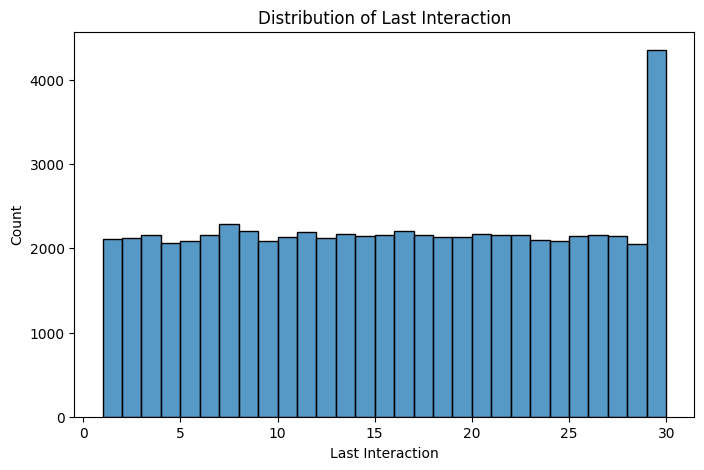

In [12]:
# Last Interaction
plt.figure(figsize=(8,5))

sns.histplot(
    df['Last Interaction'],
    binwidth=1,
    kde=False
)

plt.title('Distribution of Last Interaction')
plt.xlabel('Last Interaction')
plt.ylabel('Count')

plt.show()

###Анализ зависимости признаков от Churn

Наиболее значимое влияние на churn оказывают признаки `Support Calls`,`Payment Delay`. В обоих случаях наблюдается явный сдвиг распределений: клиенты с большим количеством обращений в поддержку и более частыми задержками платежей чаще покидают сервис.
`Tenure` также демонстрирует зависимость, однако результат является нетипичным: в данном датасете клиенты с большим сроком использования чаще уходят.
Остальные признаки (`Age`, `Usage Frequency`, `Total Spend`, `Last Interaction`) не показывают значимых различий между группами, что указывает на их слабую предсказательную способность.

Признак `CustomerID` не несёт полезной информации и должен быть исключён из модели.

`Payement Delay` имеет точки внизу - выбросы, то есть значения вне нормы (значения, которые сильно дальше, чем остальные), т.е. есть клиенты, которые ушли (Churn = 1), НО они имели маленькую задержку платежей

In [ ]:
df.groupby('Churn').mean()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
df.groupby('Churn').mean(numeric_only=True)

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
Churn,,,,,,,,
0,22846.794959,41.132700,28.826481,16.042915,4.500753,12.453086,560.541956,15.521944
1,42566.027121,42.902404,35.515200,14.010593,6.400617,22.334897,519.336143,15.473191


Несмотря на различия в среднем значении CustomerID, данный признак является идентификатором и не несёт смысловой нагрузки, поэтому он будет исключён из модели (модель может воспринять, что чем меньше значение id, тем вероятнее клиент уйдет, условно "старые" имеют меньший айдишник, чем новые, которые "Типо" считались бы не в зоне риска)

Я понимаю, что в среднем ...
- ушедшие клиенты чаще обращались в поддержку;
- ушедшие клиенты чаще задерживали платежи.

In [ ]:
df_model = df.drop(columns=['CustomerID'])

X = df_model.drop("Churn", axis=1)
y = df_model['Churn']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [ ]:
X_train.shape

(45061, 12)

In [ ]:
X_train.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
5871,54,7,29,0,27,568,16,False,True,False,False,False
40570,61,49,10,10,0,151,21,False,True,False,False,False
200,36,24,29,1,26,566,8,True,True,False,True,False
64037,59,27,12,9,24,257,9,False,False,False,True,False
13249,30,18,8,0,24,997,17,False,True,False,True,False


In [ ]:
X_train, X_val = X_train.aligh(X_val, join='Left', axis=1, fill_value=0)
X_train, X_test = X_train.aligh(X_test, join='Left', axis=1, fill_value=0)

AttributeError: 'DataFrame' object has no attribute 'aligh'

In [ ]:
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [ ]:
C_values = [0.01, 0.1, 1, 10]
max_iters = [100, 300, 700]

best_score = 0
best_params = {}

for C in C_values:
  for max_iter in max_iters:
    model = LogisticRegression(C=C, max_iter=max_iter)
    model.fit(X_train, y_train)
    y_val_pred = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, y_val_pred)

    print(f'C={C}, max_iter={max_iter}, ROC-AUC={score:.4f}')

    if score > best_score:
      best_score = score
      best_params = {'C': C, 'max_iter': max_iter}

print(best_params)
print(best_score)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=0.01, max_iter=100, ROC-AUC=0.9074


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=0.01, max_iter=300, ROC-AUC=0.9110
C=0.01, max_iter=700, ROC-AUC=0.9110


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, max_iter=100, ROC-AUC=0.8910


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, max_iter=300, ROC-AUC=0.9079
C=10, max_iter=700, ROC-AUC=0.9111
{'C': 1, 'max_iter': 700}
0.91106155995893


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
best_model = LogisticRegression(**best_params)
best_model.fit(X_train, y_train)
y_test_pred = best_model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_test_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


np.float64(0.902898294016008)

In [ ]:
for coef, name in zip(best_model.coef_[0], best_model.feature_names_in_):
  print(coef, name)

0.019289981695573787 Age
0.03572390740801059 Tenure
-0.05909743446095622 Usage Frequency
0.328893651119422 Support Calls
0.21005400060591103 Payment Delay
-0.0009926989054603367 Total Spend
-0.0013822152123386382 Last Interaction
-1.1376912659909333 Gender_Male
-0.07521591957453665 Subscription Type_Premium
-0.06365935948599702 Subscription Type_Standard
0.3381393578977773 Contract Length_Monthly
-0.15122853095602518 Contract Length_Quarterly


АНАЛИЗИРОВАТЬ КОЭФЫ Регрессии

In [ ]:
best_model.feature_names_in_

array(['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Gender_Male',
       'Subscription Type_Premium', 'Subscription Type_Standard',
       'Contract Length_Monthly', 'Contract Length_Quarterly'],
      dtype=object)

ROC-AUC_1 = 0,911

ROC-AUC_2 = 0,9029

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

def run_experiment(X, y):

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )


    X_train = pd.get_dummies(X_train, drop_first=True)
    X_val = pd.get_dummies(X_val, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)


    X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)


    C_values = [0.01, 0.1, 1, 10]
    max_iters = [100, 300, 700]

    best_score = 0
    best_params = {}

    for C in C_values:
        for max_iter in max_iters:
            model = LogisticRegression(C=C, max_iter=max_iter)
            model.fit(X_train, y_train)

            y_val_pred = model.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, y_val_pred)

            if score > best_score:
                best_score = score
                best_params = {'C': C, 'max_iter': max_iter}


    best_model = LogisticRegression(**best_params)
    best_model.fit(X_train, y_train)

    y_test_pred = best_model.predict_proba(X_test)[:, 1]
    test_score = roc_auc_score(y_test, y_test_pred)

    return best_params, best_score, test_score

ВАЖНЫЕ ПРИЗНАКИ

In [ ]:
features_important = ['Tenure', 'Support Calls', 'Payment Delay']

X_imp = df[features_important]
y = df['Churn']

run_experiment(X_imp, y)

({'C': 0.1, 'max_iter': 100},
 np.float64(0.8848210764984227),
 np.float64(0.8803439741116573))

In [ ]:
X_all = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

run_experiment(X_all, y)

({'C': 0.01, 'max_iter': 100},
 np.float64(0.9110924846262684),
 np.float64(0.90292176790174))

In [ ]:
X_num = df.select_dtypes(include=['int64', 'float64']).drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

run_experiment(X_num, y)

({'C': 0.01, 'max_iter': 100},
 np.float64(0.8971230080901339),
 np.float64(0.8917003046875974))

In [17]:
# sklearn GridSearch - sklearn pipeline (для scaler)!!!
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split


In [18]:
features = ['Tenure', 'Support Calls', 'Payment Delay']

X = df[features]
y = df['Churn']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [21]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__max_iter': [100, 300, 700]
}

In [22]:
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='roc_auc'
)

In [23]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__max_iter': [100, 300, 700]},
             scoring='roc_auc')

In [24]:
print(grid.best_params_)

{'model__C': 1, 'model__max_iter': 100}


In [25]:
print(grid.best_score_)

0.8780642433927215


In [26]:
y_pred = grid.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_pred)

np.float64(0.8850975187574612)

In [27]:
# Ручное правило

def business_classifier(row):

    if row['Payment Delay'] > 20:
        return 1

    elif row['Support Calls'] > 6:
        return 1

    else:
        return 0

# Создаем предсказание
df['business_pred'] = df.apply(
    business_classifier,
    axis=1
)


# смотрим первые результаты
df[['Churn', 'business_pred']].head()


# импортируем метрики
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score


# accuracy
accuracy = accuracy_score(
    df['Churn'],
    df['business_pred']
)

print('Accuracy:', accuracy)


# ROC-AUC
roc_auc = roc_auc_score(
    df['Churn'],
    df['business_pred']
)

print('ROC-AUC:', roc_auc)

Accuracy: 0.7043992916394818
ROC-AUC: 0.7133613338753827


In [30]:
# RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(
    y_test,
    rf_pred
)

print('Random Forest ROC-AUC:', rf_auc)

Random Forest ROC-AUC: 0.9125068443621456


In [31]:
# KNN (k-nearest neighbors)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_pipe.fit(X_train, y_train)

knn_pred = knn_pipe.predict_proba(X_test)[:,1]

knn_auc = roc_auc_score(
    y_test,
    knn_pred
)

print('KNN ROC-AUC:', knn_auc)

KNN ROC-AUC: 0.9112626481222593


Полученные результаты:

- Logistic Regression: ROC-AUC ≈ 0.885
- Random Forest: ROC-AUC ≈ 0.913
- KNN: ROC-AUC ≈ 0.911

In [29]:
df_no_objects = df.select_dtypes(exclude=['object'])

In [ ]:
df_no_objects.corr()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
CustomerID,1.000000,0.043287,0.103296,-0.062699,0.164175,0.290684,-0.037068,-0.003718,0.529832
Age,0.043287,1.000000,-0.007763,-0.038331,0.005014,-0.016132,0.006490,-0.000148,0.063457
Tenure,0.103296,-0.007763,1.000000,0.023485,0.060065,0.055963,0.009474,0.005770,0.195327
Usage Frequency,-0.062699,-0.038331,0.023485,1.000000,-0.014072,0.031132,0.001527,-0.009192,-0.115098
Support Calls,0.164175,0.005014,0.060065,-0.014072,1.000000,0.064298,0.021750,0.001666,0.304631
Payment Delay,0.290684,-0.016132,0.055963,0.031132,0.064298,1.000000,-0.031119,-0.008076,0.557386
Total Spend,-0.037068,0.006490,0.009474,0.001527,0.021750,-0.031119,1.000000,-0.007692,-0.078867
Last Interaction,-0.003718,-0.000148,0.005770,-0.009192,0.001666,-0.008076,-0.007692,1.000000,-0.002818
Churn,0.529832,0.063457,0.195327,-0.115098,0.304631,0.557386,-0.078867,-0.002818,1.000000


In [ ]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


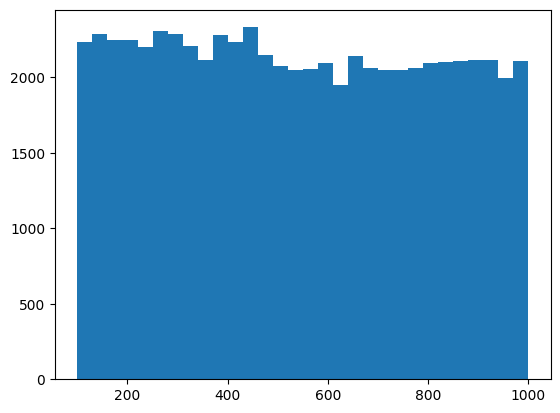

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['Total Spend'], bins=30)
plt.show()

In [ ]:
df['Contract Length'].value_counts()

,count
Contract Length,
Monthly,22130
Annual,21410
Quarterly,20834


In [ ]:
df_no_objects.groupby('Churn').agg(['mean', 'median'])

CustomerID                 Age            Tenure         \
               mean   median       mean median       mean median   
Churn                                                              
0      22846.794959  22866.0  41.132700   41.0  28.826481   27.0   
1      42566.027121  49128.0  42.902404   44.0  35.515200   37.0   

      Usage Frequency        Support Calls        Payment Delay         \
                 mean median          mean median          mean median   
Churn                                                                    
0           16.042915   16.0      4.500753    4.0     12.453086   12.0   
1           14.010593   14.0      6.400617    7.0     22.334897   23.0   

      Total Spend        Last Interaction         
             mean median             mean median  
Churn                                             
0      560.541956  568.0        15.521944   16.0  
1      519.336143  491.0        15.473191   15.0

In [ ]:
df_main = df[['CustomerID', 'Tenure', 'Support Calls', 'Payment Delay', 'Churn']]

In [ ]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,1,False,False,False,True,False
1,41,28,28,7,13,584,20,0,False,False,True,True,False
2,47,27,10,2,29,757,21,0,True,True,False,False,False
3,35,9,12,5,17,232,18,0,True,True,False,False,True
4,53,58,24,9,2,533,18,0,False,False,True,False,False


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:

model = LogisticRegression(max_iter=700)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=700)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
?LogisticRegression

In [ ]:
def fit_predict(df_main, max_iter=100, scale=False):
  X = df_main.drop(columns=['Churn', 'CustomerID'])
  y = df_main['Churn']

  X_train, X_test, y_train, y_test = train_test_split(
      X, y,
      test_size = 0.2,
      random_state=42
  )

  if scale:
    sc = StandardScaler().fit(X_train)
    X_train = sc.transform(X_train)
    X_test = sc.transform(X_test)

  model = LogisticRegression(max_iter=max_iter, C=10)
  model.fit(X_train, y_train)


  y_pred = model.predict(X_test)

  print(classification_report(y_test, y_pred))
  return model

In [ ]:
model = fit_predict(df_main, 1000, True)

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      6793
           1       0.80      0.82      0.81      6082

    accuracy                           0.82     12875
   macro avg       0.81      0.82      0.81     12875
weighted avg       0.82      0.82      0.82     12875



In [ ]:
model = fit_predict(df_main, 10, False)

              precision    recall  f1-score   support

           0       0.81      0.64      0.71      6793
           1       0.67      0.83      0.74      6082

    accuracy                           0.73     12875
   macro avg       0.74      0.73      0.73     12875
weighted avg       0.74      0.73      0.73     12875



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model = fit_predict(df_main, 20, False)

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      6793
           1       0.80      0.82      0.81      6082

    accuracy                           0.82     12875
   macro avg       0.81      0.82      0.81     12875
weighted avg       0.82      0.82      0.82     12875



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model = fit_predict(df_main, 100, True)

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      6793
           1       0.80      0.82      0.81      6082

    accuracy                           0.82     12875
   macro avg       0.81      0.82      0.81     12875
weighted avg       0.82      0.82      0.82     12875



In [ ]:
df_main

,CustomerID,Tenure,Support Calls,Payment Delay,Churn
0,1,25,4,27,1
1,2,28,7,13,0
2,3,27,2,29,0
3,4,9,5,17,0
4,5,58,9,2,0
...,...,...,...,...,...
64369,64370,33,6,21,1
64370,64371,6,5,22,1
64371,64372,39,8,30,1
64372,64373,18,7,22,1


In [ ]:
model.coef_

array([[0.49110064, 0.87884707, 1.66765397]])

In [ ]:
?fit_predict(df_main, 250)

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      6793
           1       0.80      0.82      0.81      6082

    accuracy                           0.82     12875
   macro avg       0.81      0.82      0.81     12875
weighted avg       0.82      0.82      0.82     12875



LogisticRegression(max_iter=2000)

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      6793
           1       0.84      0.83      0.84      6082

    accuracy                           0.85     12875
   macro avg       0.85      0.85      0.85     12875
weighted avg       0.85      0.85      0.85     12875



In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Acciracy")
print(accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Acciracy
0.8462912621359223
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      6793
           1       0.84      0.83      0.84      6082

    accuracy                           0.85     12875
   macro avg       0.85      0.85      0.85     12875
weighted avg       0.85      0.85      0.85     12875



In [ ]:
  X = df_main.drop(columns=['Churn', 'CustomerID'])
  y = df_main['Churn']
  X_train, X_test, y_train, y_test = train_test_split(
      X, y,
      test_size = 0.2,
      random_state=42
  )

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


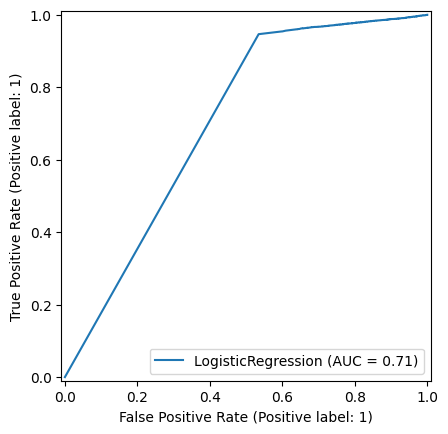

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split


#model = LogisticRegression().fit(X_train, y_train)

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()


Classes are `0` and `1`:

#0*- the client didn't leave
`Precision = 0.85` - in 85% of cases, the model correctly assigns the client to the group of those who did not leave

`Recall = 0.83` - in 83% of cases, the model correcly assigns customers who actually stay

`F1-score` = 2 * Precision*Recall / (Precision+Recall) - balance between *precision* and *recall*, how well the model captures the required class = `0.84`

#1* - the client left
`Precision = 0.82` - in 82% of cases, the model correctly identifies customers as those who will leave

`Recall = 0.83` - in 83% of cases, the model correctly identifies customers who actually left

`F1-score` = 0.82

---
`Recall = 0.83` - the model finds 83% of actual customers who leave

`Accuracy = 0.83` - the model correctly classifies 83% of clients

